# Master Results Notebook for Paper Production

This notebook serves as the primary driver for generating the final, publication-quality figures and tables for the paper. It leverages the consolidated logic in `src/sed_pipeline/` to ensure zero data loss and reproducible results.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src.sed_pipeline import config, data_io, composite_math, photometry, visualization, analysis

# Styling for publication
plt.style.use('default')
sns.set_context("paper", font_scale=1.5)
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Configurations and Base Models

We start by loading the necessary filters (UVJ, ugr, IRAC) and the base Type 1 and Type 2 AGN SKIRTOR models using parameters defined in the thesis methodology.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Skirtor')
brown_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Brown', '2014', 'Rest')

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

## 2. Generate Composite SEDs and Calculate Colours

We will iterate over the alpha values, calculate composite SEDs for all templates and both AGN types, and compute their colours. For `ugr` and `IRAC` diagrams, specific artificial redshifting is applied to reflect survey selections.

In [3]:
results = []
alphas = config.ALPHA_VALUES

# Target redshifts for artificial redshifting
z_ugr = 3.0 # Within the U-dropout target range of 2.6 < z < 3.6
z_irac = 0.0 # Restframe for standard Lacy wedge demo

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}")
    
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            
            # Calculate UVJ (restframe)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            
            # Calculate ugr (redshifted to z=3.0)
            ug, gr = photometry.calculate_ugr_colours(comp_sed, filters['u'], filters['g'], filters['r'], redshift=z_ugr)
            
            # Calculate IRAC (restframe)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=z_irac)
            
            results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'U-V': uv,
                'V-J': vj,
                'u-g': ug,
                'g-r': gr,
                'f5836': f5836,
                'f8045': f8045
            })

df_results = pd.DataFrame(results)
print("Processed all composite combinations.")

Processing template 1/128: Arp_118
Processing template 2/128: Arp_256_N
Processing template 3/128: Arp_256_S
Processing template 4/128: CGCG_049-057
Processing template 5/128: CGCG_436-030
Processing template 6/128: CGCG_453-062
Processing template 7/128: Haro_06
Processing template 8/128: IC_0691
Processing template 9/128: IC_0860
Processing template 10/128: IC_0883
Processing template 11/128: IC_4051
Processing template 12/128: IC_4553
Processing template 13/128: IC_5298
Processing template 14/128: III_Zw_035
Processing template 15/128: II_Zw_096
Processing template 16/128: IRAS_08572+3915
Processing template 17/128: IRAS_17208-0014
Processing template 18/128: Mrk_0331
Processing template 19/128: Mrk_0475
Processing template 20/128: Mrk_0930
Processing template 21/128: Mrk_1450
Processing template 22/128: Mrk_1490
Processing template 23/128: Mrk_33
Processing template 24/128: NGC_0337
Processing template 25/128: NGC_0474
Processing template 26/128: NGC_0520
Processing template 27/128

## 3. Colour Evolution Evolution Plots

These plots show how individual galaxies move through colour-colour space as the AGN contribution ($\alpha$) increases from 0 to 1.

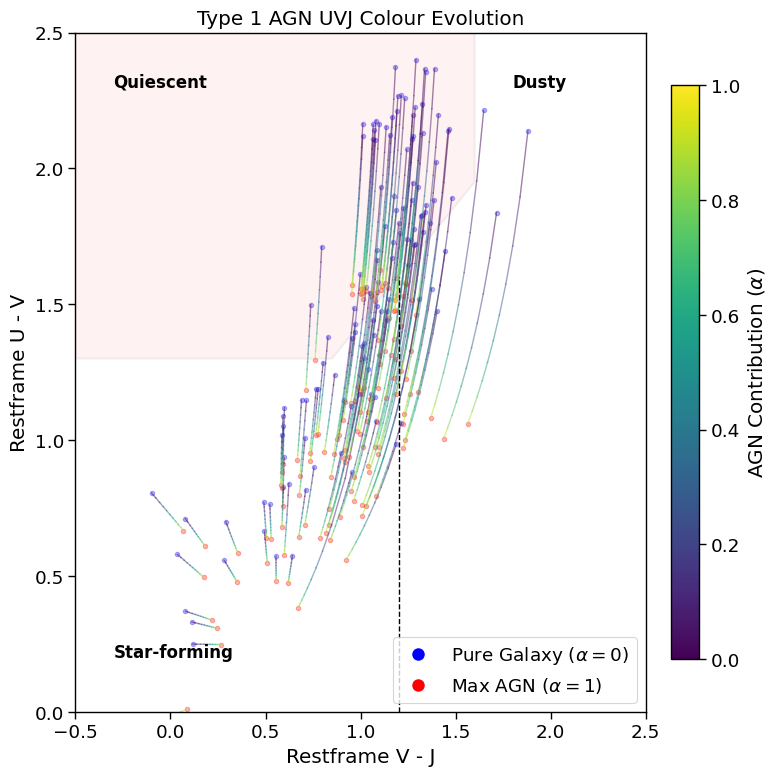

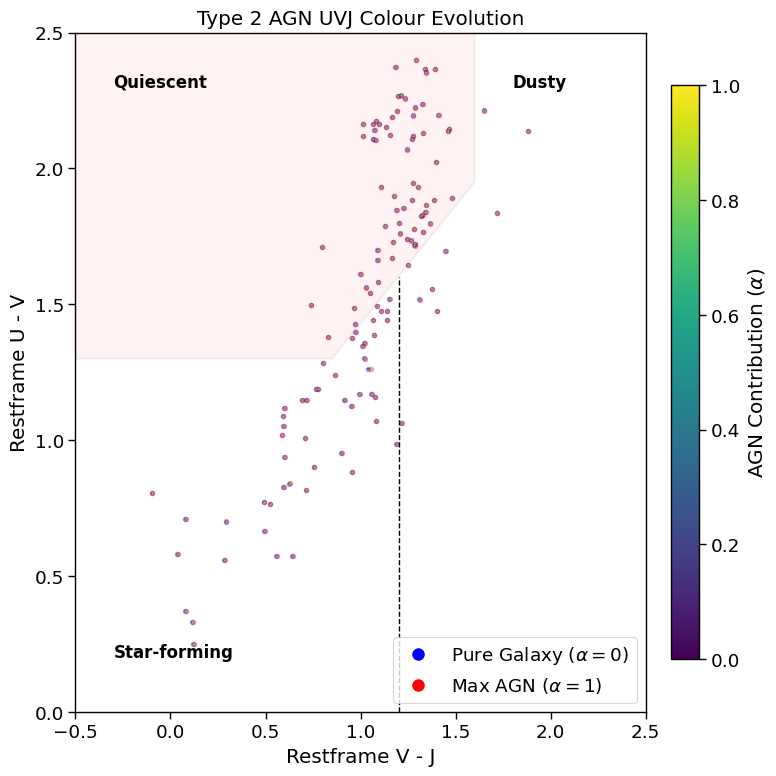

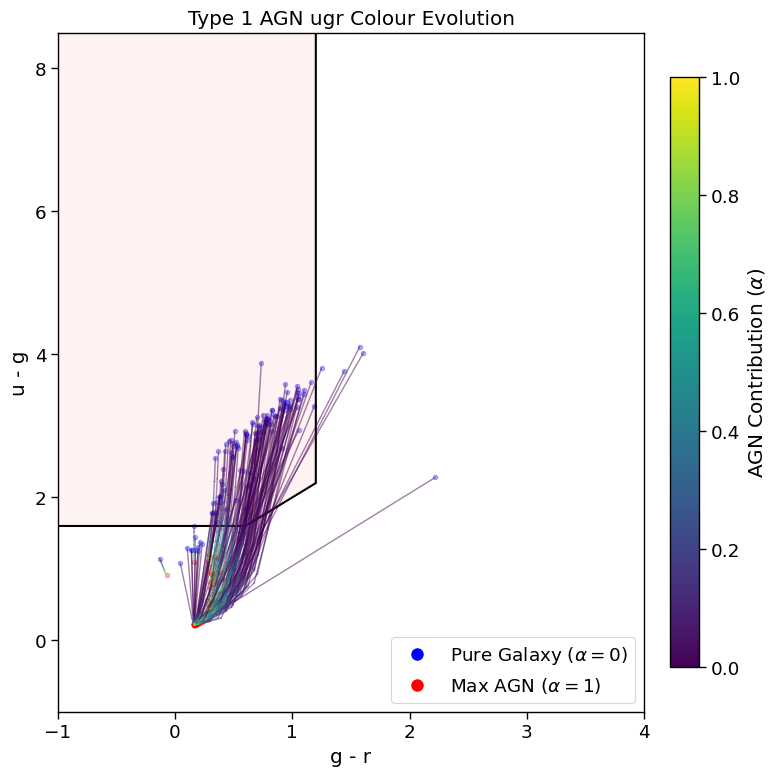

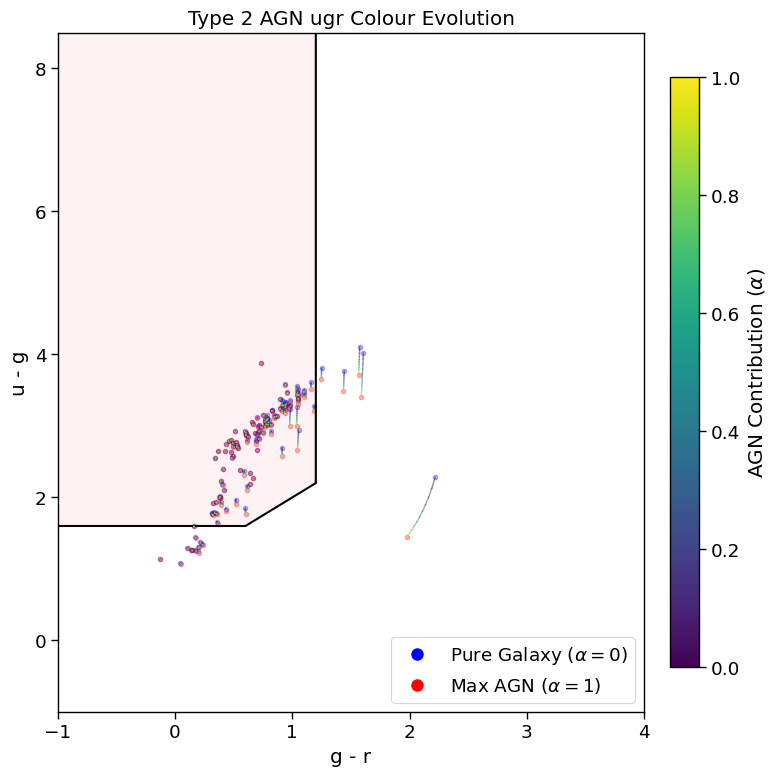

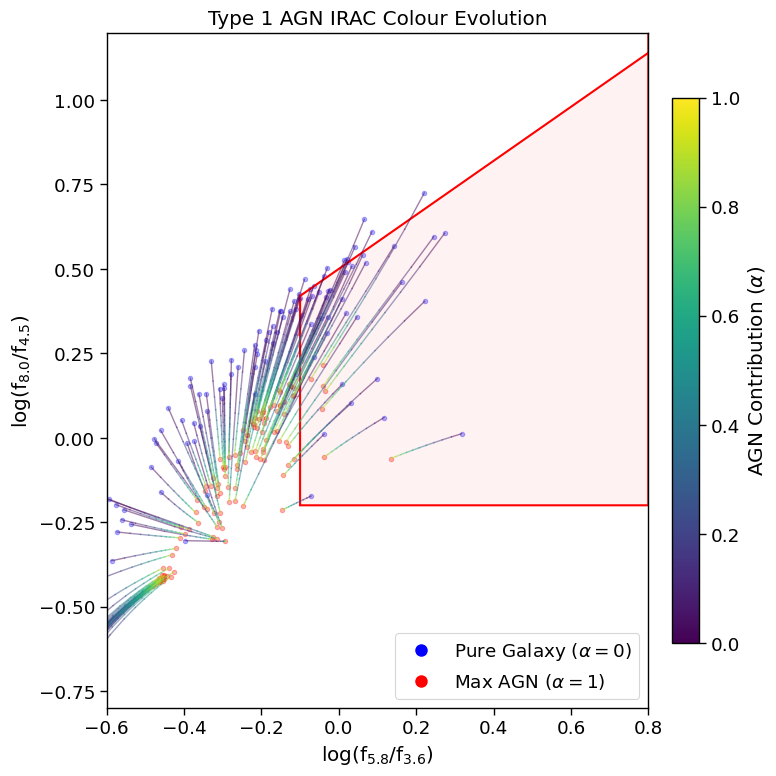

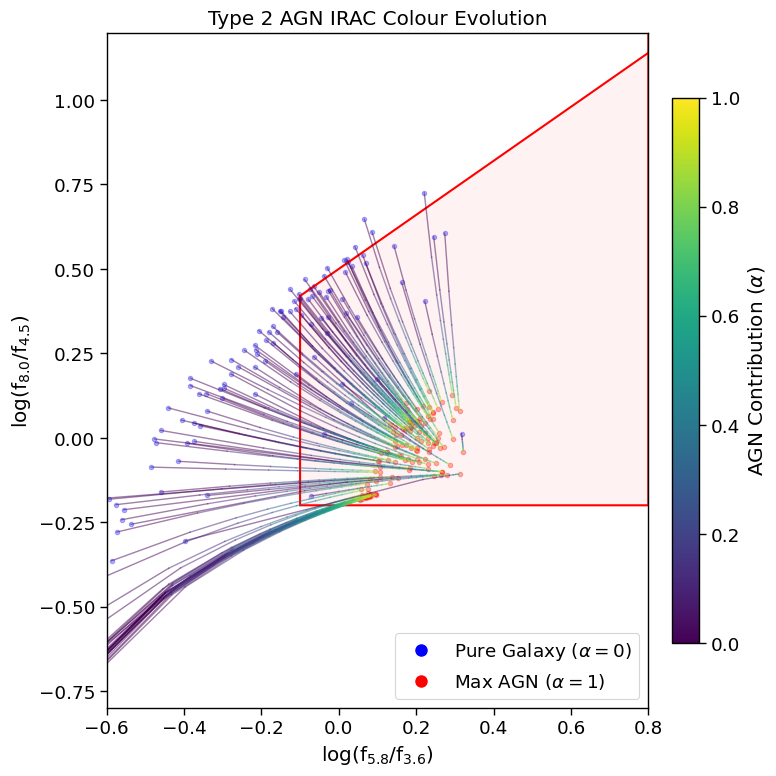

In [4]:
def plot_evolution_tracks(df, agn_type, x_col, y_col, plot_func, title, output_name):
    fig, ax = plt.subplots(figsize=(8, 8))
    subset = df[df['AGN_Type'] == agn_type]
    
    # Use a colormap for alpha
    cmap = plt.cm.viridis
    
    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        
        # Plot segments with color coding for alpha
        for i in range(len(temp_df)-1):
            alpha_val = temp_df['Alpha'].iloc[i]
            ax.plot(temp_df[x_col].iloc[i:i+2], temp_df[y_col].iloc[i:i+2], 
                    color=cmap(alpha_val), alpha=0.5, linewidth=1)
        
        # Mark start (pure galaxy) and end (max AGN)
        ax.scatter(temp_df[x_col].iloc[0], temp_df[y_col].iloc[0], color='blue', s=10, alpha=0.3)
        ax.scatter(temp_df[x_col].iloc[-1], temp_df[y_col].iloc[-1], color='red', s=10, alpha=0.3)
            
    # Apply formatting
    plot_func([], [], ax=ax, title=title)
    
    # Custom legend
    custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=r'Pure Galaxy ($\alpha=0$)'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label=r'Max AGN ($\alpha=1$)')]
    ax.legend(handles=custom_lines, loc='lower right')
    
    # Add colorbar for Alpha
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'AGN Contribution ($\alpha$)')

    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, output_name), bbox_inches='tight')
    return fig, ax

plot_evolution_tracks(df_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram, 
                      'Type 1 AGN UVJ Colour Evolution', 'Paper_UVJ_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram, 
                      'Type 2 AGN UVJ Colour Evolution', 'Paper_UVJ_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'g-r', 'u-g', visualization.plot_ugr_diagram, 
                      'Type 1 AGN ugr Colour Evolution', 'Paper_ugr_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'g-r', 'u-g', visualization.plot_ugr_diagram, 
                      'Type 2 AGN ugr Colour Evolution', 'Paper_ugr_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'f5836', 'f8045', visualization.plot_irac_diagram, 
                      'Type 1 AGN IRAC Colour Evolution', 'Paper_IRAC_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'f5836', 'f8045', visualization.plot_irac_diagram, 
                      'Type 2 AGN IRAC Colour Evolution', 'Paper_IRAC_Evolution_Type2.pdf')

plt.show()

## 3b. SWIRE Template Evolution (Fig 3)

Generating initial composite modelling using the SWIRE template library.

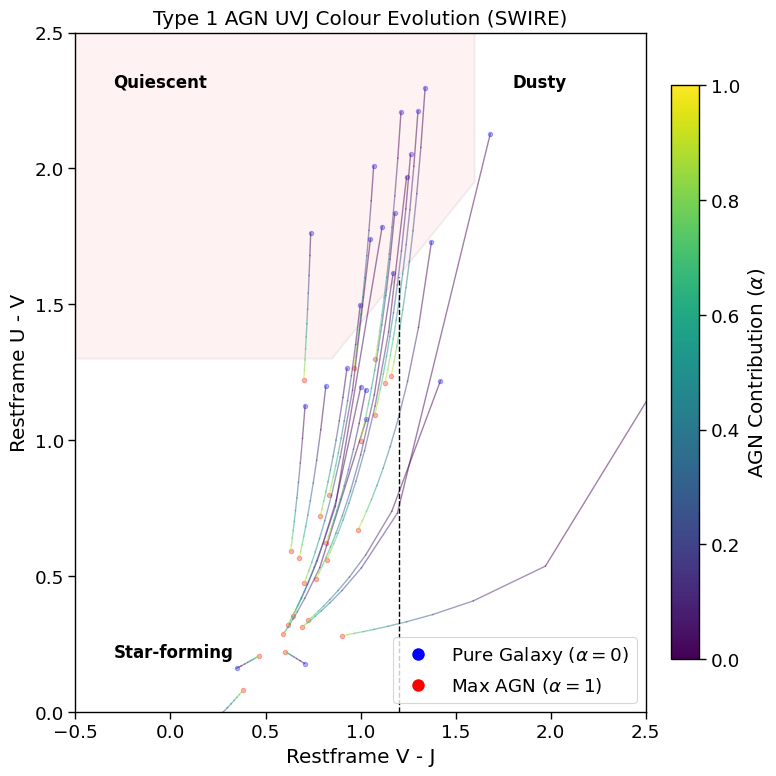

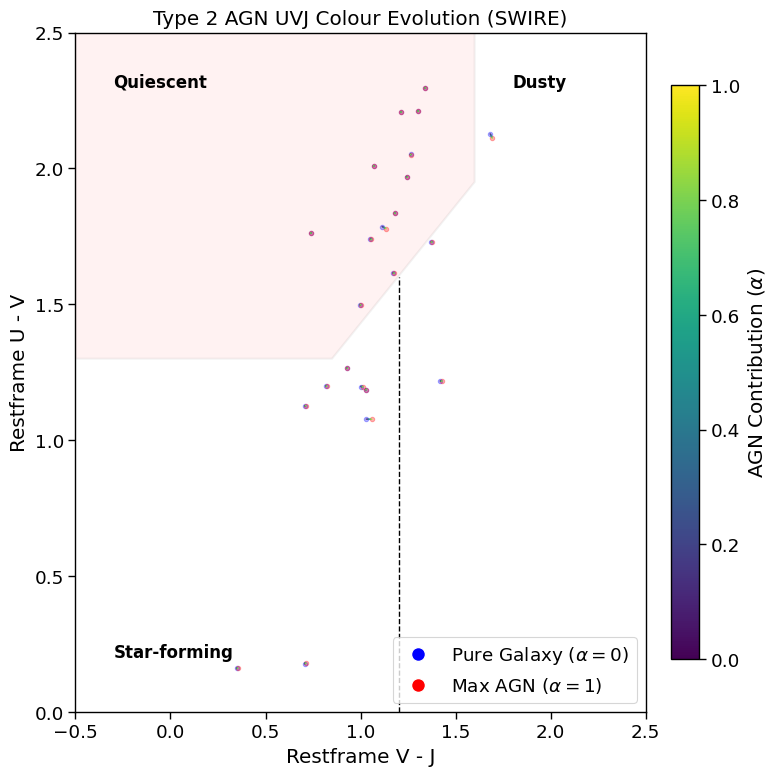

In [5]:
# Load SWIRE Templates
swire_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'SWIRE')
swire_templates, swire_names = data_io.read_swire_templates(swire_dir)

swire_results = []

for t_idx, gal_sed in enumerate(swire_templates):
    gal_name = swire_names[t_idx]
    
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            
            swire_results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'U-V': uv,
                'V-J': vj
            })

df_swire_results = pd.DataFrame(swire_results)

# Plot SWIRE tracks
plot_evolution_tracks(df_swire_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram, 
                      'Type 1 AGN UVJ Colour Evolution (SWIRE)', 'SWIREType1AGNUVJ.png')
plot_evolution_tracks(df_swire_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram, 
                      'Type 2 AGN UVJ Colour Evolution (SWIRE)', 'SWIREType2AGNUVJ.png')
plt.show()


## 4. Selection Completeness Analysis

Evaluating how well the standard selection wedges (UVJ, ugr dropout, Lacy IRAC) identify their targets as AGN contamination increases.

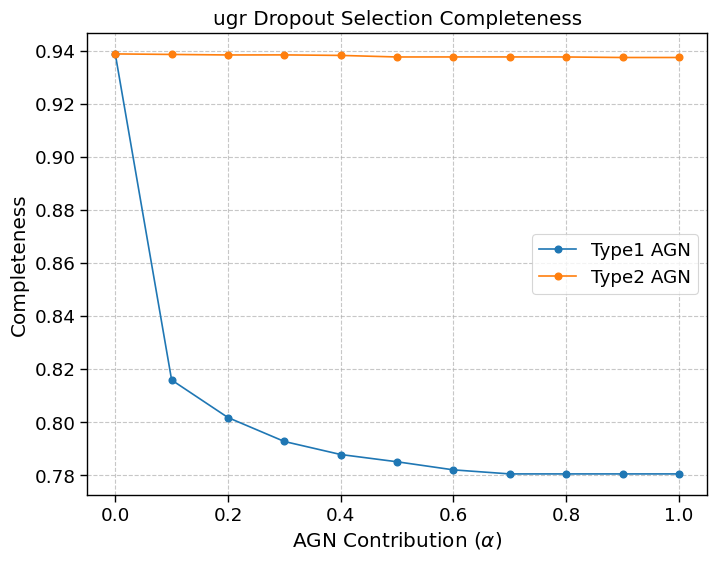

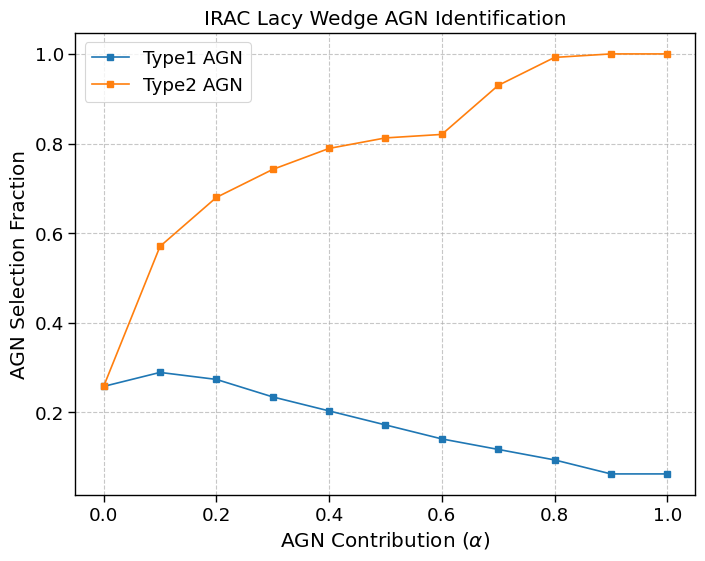

In [6]:
# 1. ugr Dropout Completeness (from redshift grid data)
grid_file = os.path.join(config.PROCESSED_DATA_DIR, 'ugr_completeness_grid.csv')
if os.path.exists(grid_file):
    df_grid = pd.read_csv(grid_file)
    df_comp_ugr = analysis.calculate_completeness_from_df(df_grid)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    for agn_type in df_comp_ugr['AGN_Type'].unique():
        subset = df_comp_ugr[df_comp_ugr['AGN_Type'] == agn_type]
        ax.plot(subset['Alpha'], subset['Completeness'], marker='o', label=f'{agn_type} AGN')
        
    ax.set_xlabel(r'AGN Contribution ($\alpha$)')
    ax.set_ylabel('Completeness')
    ax.set_title('ugr Dropout Selection Completeness')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_ugr_Completeness.pdf'), bbox_inches='tight')
    plt.show()

# 2. IRAC Lacy Wedge Completeness (calculated from df_results)
def calculate_irac_completeness(df):
    res = []
    for agn_type in df['AGN_Type'].unique():
        subset = df[df['AGN_Type'] == agn_type]
        for alpha in subset['Alpha'].unique():
            alpha_df = subset[subset['Alpha'] == alpha]
            in_wedge = analysis.is_in_lacy_wedge(alpha_df['f5836'], alpha_df['f8045'])
            # For IRAC, completeness is fraction identified as AGN
            completeness = np.sum(in_wedge) / len(alpha_df)
            res.append({'AGN_Type': agn_type, 'Alpha': alpha, 'Completeness': completeness})
    return pd.DataFrame(res)

df_comp_irac = calculate_irac_completeness(df_results)

fig, ax = plt.subplots(figsize=(8, 6))
for agn_type in df_comp_irac['AGN_Type'].unique():
    subset = df_comp_irac[df_comp_irac['AGN_Type'] == agn_type]
    ax.plot(subset['Alpha'], subset['Completeness'], marker='s', label=f'{agn_type} AGN')
    
ax.set_xlabel(r'AGN Contribution ($\alpha$)')
ax.set_ylabel('AGN Selection Fraction')
ax.set_title('IRAC Lacy Wedge AGN Identification')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_IRAC_Completeness.pdf'), bbox_inches='tight')
plt.show()

## 5. Statistical Tables (LaTeX Exports)

Exporting the final results to LaTeX for inclusion in the paper.

In [7]:
def calculate_uvj_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for alpha in subset['Alpha'].unique():
        alpha_df = subset[subset['Alpha'] == alpha]
        initial_df = subset[subset['Alpha'] == 0.0]
        
        vj_alpha = alpha_df['V-J'].values
        uv_alpha = alpha_df['U-V'].values
        vj_init = initial_df['V-J'].values
        uv_init = initial_df['U-V'].values
        
        mean_offset = analysis.calculate_mean_vector_offset(vj_alpha, uv_alpha, vj_init, uv_init)
        offsets.append({'Alpha': alpha, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

off1 = calculate_uvj_offsets(df_results, 'Type1')
off2 = calculate_uvj_offsets(df_results, 'Type2')

table_df = pd.DataFrame({
    r'AGN Contribution ($\\alpha$)': [f"{int(a*100)}\\%" for a in alphas],
    'Type 1 Offset (dex)': off1['Mean_Offset'].round(3),
    'Type 2 Offset (dex)': off2['Mean_Offset'].round(3)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, caption=r"Mean vector offset for Type 1 and Type 2 AGN composites in the UVJ diagram.", label="tab:UVJ_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)

print("Exported UVJ Vector Offset table.")

,AGN Contribution ($\\alpha$),Type 1 Offset (dex),Type 2 Offset (dex)
0,0\%,0.000,0.000
1,10\%,0.090,0.000
2,20\%,0.165,0.000
3,30\%,0.229,0.001
4,40\%,0.285,0.001
5,50\%,0.335,0.001
6,60\%,0.380,0.001
7,70\%,0.420,0.002
8,80\%,0.457,0.002
9,90\%,0.491,0.002


ImportError: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.

## 6. UVJ Population Fraction Analysis

This section analyzes how AGN contamination causes galaxies to migrate between the Star-forming, Quiescent, and Dusty regions of the UVJ diagram.

In [ ]:
def plot_uvj_fractions(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    alphas = subset['Alpha'].unique()
    
    q_fracs = []
    sf_fracs = []
    d_fracs = []
    
    for alpha in alphas:
        alpha_df = subset[subset['Alpha'] == alpha]
        classifications = analysis.classify_uvj(alpha_df['V-J'], alpha_df['U-V'])
        q, sf, d = analysis.calculate_population_fractions(classifications)
        q_fracs.append(q)
        sf_fracs.append(sf)
        d_fracs.append(d)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(alphas, q_fracs, label='Quiescent', color='red', marker='o')
    ax.plot(alphas, sf_fracs, label='Star-forming', color='blue', marker='s')
    ax.plot(alphas, d_fracs, label='Dusty', color='green', marker='^')
    
    ax.set_xlabel(r'AGN Contribution ($\\alpha$)')
    ax.set_ylabel('Population Fraction')
    ax.set_title(f'UVJ Population Migration: {agn_type} AGN')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim([0, 1.1])
    
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, f'Paper_UVJ_Fractions_{agn_type}.pdf'), bbox_inches='tight')
    plt.show()

plot_uvj_fractions(df_results, 'Type1')
plot_uvj_fractions(df_results, 'Type2')

## 7. Composite SED Progression (Fig 6)

Recreating Figure 6: 1D SED progression for representative Star-forming, Quiescent, and Dusty galaxies with increasing Type 1 AGN contribution.

In [ ]:
# Representative templates from Brown (GALSEDATLAS) set
# Star-forming: NGC_0337, Quiescent: NGC_4552, Dusty: IC_4553 (Arp 220)
rep_templates = {
    'Star-forming': 'NGC_0337',
    'Quiescent': 'NGC_4552',
    'Dusty': 'IC_4553'
}

comp_progression_data = {}

for pop_name, gal_name in rep_templates.items():
    if gal_name in brown_names:
        t_idx = brown_names.index(gal_name)
        gal_sed = brown_templates[t_idx]
        
        comp_progression_data[pop_name] = {}
        for alpha in alphas:
            # Fig 6 specifically uses Type 1 AGN as per the paper description
            comp_sed = composite_math.create_composite_sed(agn_type1, gal_sed, alpha)
            comp_progression_data[pop_name][alpha] = comp_sed

# Plot using the new visualization tool
visualization.plot_composite_sed_progression(comp_progression_data, filters, 
                                             output_path=os.path.join(config.PROCESSED_DATA_DIR, 'CompositeSEDs_UVJ.png'))
plt.show()


## 8. Observational ZFOURGE Composites (Fig 7, 8, Table 4)

This section confirms theoretical trends using observational ZFOURGE data by tracking how the average galaxy in each UVJ region evolves with increasing Type 1 AGN contribution.

In [ ]:
# Load the pre-generated observational composite data (calculated during Honours phase)
# Note: Using relative path from notebook location
obs_csv_path = os.path.join('..\outputs', 'composite_seds', 'ZFOURGE_obsevational_composites_fluxesType1AGN.csv')
if os.path.exists(obs_csv_path):
    df_obs = pd.read_csv(obs_csv_path, index_col=0)
    
    # Re-classify Alpha=0 galaxies
    df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])

    # Fig 7: UVJ Density at Alpha=50%
    uv_50 = df_obs['U_50'] - df_obs['V_50']
    vj_50 = df_obs['V_50'] - df_obs['J_50']
    visualization.plot_uvj_diagram(vj_50, uv_50, classifications=df_obs['Classification'], 
                                   show_density=True, title="ZFOURGE UVJ Density (Alpha=50%)")
    plt.show()

    # Fig 8: Average Region Tracks
    regions = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    colors = {0: 'red', 1: 'blue', 2: 'green'}
    fig, ax = plt.subplots(figsize=(8, 8))
    visualization.plot_uvj_diagram([], [], ax=ax, title="ZFOURGE Average Region Tracks")
    
    for cid, name in regions.items():
        sub = df_obs[df_obs['Classification'] == cid]
        if len(sub) == 0: continue
        tvj = [sub[f'V_{a}'].mean() - sub[f'J_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        tuv = [sub[f'U_{a}'].mean() - sub[f'V_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        ax.plot(tvj, tuv, marker='o', color=colors[cid], label=name, lw=2)
        ax.annotate('', xy=(tvj[-1], tuv[-1]), xytext=(tvj[0], tuv[0]),
                    arrowprops=dict(arrowstyle="->", color=colors[cid], lw=1.5, alpha=0.5))
    ax.legend(loc='lower right')
    plt.show()
else:
    print(f"Observational composite file not found at: {obs_csv_path}")


## 9. CIGALE Decomposed Population Analysis (Fig 9, 10, 11)

Final observational support: analyzing the UVJ shift of the entire ZFOURGE population when AGN light is removed via CIGALE SED decomposition.

In [ ]:
# Load CIGALE summary table
cigale_csv = os.path.join('..\datasets', 'full_zfourge_decomposed', 'zfourge_full_final.csv')
if os.path.exists(cigale_csv):
    df_cig = pd.read_csv(cigale_csv)
    z_col = 'zpk_x' if 'zpk_x' in df_cig.columns else 'zpk'

    # Fig 9: Side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    visualization.plot_uvj_diagram(df_cig['VJ_Full'], df_cig['UV_Full'], ax=axes[0], title="Full Galaxy (Host + AGN)")
    visualization.plot_uvj_diagram(df_cig['VJ_Decomposed'], df_cig['UV_Decomposed'], ax=axes[1], title="Decomposed Host (AGN Removed)")
    plt.show()

    # Fig 11: Redshift Divergence
    bins = [[0, 0.5], [0.5, 1.0], [1.0, 1.5], [1.5, 2.0], [2.0, 2.5], [2.5, 3.5]]
    fig, ax = plt.subplots(figsize=(8, 8))
    visualization.plot_uvj_diagram([], [], ax=ax, title="UVJ Divergence by Redshift")
    cmap = plt.cm.viridis
    for i, (z_min, z_max) in enumerate(bins):
        sub = df_cig[(df_cig[z_col] >= z_min) & (df_cig[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=10, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=10)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.legend(loc='lower right', title="Redshift Bins")
    plt.show()
else:
    print("CIGALE summary table not found.")
